<a href="https://colab.research.google.com/github/Suz99/CVtasks/blob/main/STALLtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q opencv-python-headless scikit-learn matplotlib numpy scipy timm

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import cv2
import os

np.random.seed(0)
print("Setup complete.")

Setup complete.


In [ ]:
class AdaptiveGaussianBranch:
    """
    One branch (spatial OR temporal) of a STALL-style detector.

    - Computes a whitening transform ONCE from an initial calibration set (frozen thereafter).
    - Scores new embeddings via the whitened Gaussian log-likelihood (Eq. 4 in the STALL paper).
    - Maintains a running mean `mu`, adapted online via EMA over GATE-ACCEPTED embeddings only.
    - Maintains a sliding window of recent scores to compute a RELATIVE percentile for the gate
      (relative to recent history, not the original calibration -- see design-doc Section 3.2/3.3
      for why a purely calibration-relative gate can never bootstrap under a real domain shift).
    """

    def __init__(self, X_init, alpha=0.08, gate_window=200, eps=1e-6):
        self.eps = eps
        self.d = X_init.shape[1]
        self.mu0, self.W = self._compute_whitening(X_init)
        self.mu = self.mu0.copy()
        self.alpha = alpha
        y0 = self._whiten(X_init, self.mu0)
        init_scores = self._loglik(y0)
        self.gate_window = gate_window
        self.recent_scores = list(init_scores[-gate_window:])

    def _compute_whitening(self, X):
        mu = X.mean(axis=0)
        Xc = X - mu
        Sigma = (Xc.T @ Xc) / X.shape[0] + self.eps * np.eye(self.d)
        eigvals, eigvecs = np.linalg.eigh(Sigma)
        eigvals = np.clip(eigvals, self.eps, None)
        W = np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T
        return mu, W

    def _whiten(self, X, mu):
        return (X - mu) @ self.W.T

    def _loglik(self, Y):
        # Eq. 4 of the STALL paper: isotropic Gaussian log-likelihood in whitened space
        return -0.5 * (self.d * np.log(2 * np.pi) + np.sum(Y ** 2, axis=-1))

    def relative_percentile(self, score):
        arr = np.sort(self.recent_scores)
        idx = np.searchsorted(arr, score, side="right")
        return idx / len(arr)

    def score(self, x):
        """Score a single embedding x (shape [d]). Returns (raw_loglik, relative_percentile)."""
        y = self._whiten(x[None, :], self.mu)[0]
        s = self._loglik(y[None, :])[0]
        perc = self.relative_percentile(s)
        self.recent_scores.append(s)
        if len(self.recent_scores) > self.gate_window:
            self.recent_scores.pop(0)
        return s, perc

    def update_mean(self, x):
        """Fold an accepted embedding into the running mean (EMA)."""
        self.mu = (1 - self.alpha) * self.mu + self.alpha * x


In [ ]:
class OnlineVideoDetector:
    """Wraps a spatial and a temporal AdaptiveGaussianBranch and combines them STALL-style."""

    def __init__(self, spatial_init, temporal_init, alpha=0.08, gate_window=200, tau_gate=0.80):
        self.spatial = AdaptiveGaussianBranch(spatial_init, alpha=alpha, gate_window=gate_window)
        self.temporal = AdaptiveGaussianBranch(temporal_init, alpha=alpha, gate_window=gate_window)
        self.tau_gate = tau_gate

    def score_video(self, frame_embeddings):
        """
        frame_embeddings: array [T, d] of per-frame encoder embeddings for one video.
        Returns: combined_percentile (higher = more "typical/real-looking"),
                 fake_score (higher = more "fake-like", for AUC where label 1 = fake),
                 per-branch (spatial_perc, temporal_perc) for diagnostics.
        """
        spat_scores = [self.spatial.score(x)[0] for x in frame_embeddings]
        spat_percs = [self.spatial.relative_percentile(s) for s in spat_scores]
        # spatial branch score for the VIDEO = the least-typical frame (paper uses max raw
        # log-lik as "most normal frame" for a slightly different framing; here we track
        # percentiles directly per design-doc simplicity)
        s_spat_idx = int(np.argmin(spat_percs))
        spat_perc_video = spat_percs[s_spat_idx]

        deltas = np.diff(frame_embeddings, axis=0)
        norms = np.linalg.norm(deltas, axis=1, keepdims=True) + 1e-8
        deltas_norm = deltas / norms
        temp_scores = [self.temporal.score(x)[0] for x in deltas_norm]
        temp_percs = [self.temporal.relative_percentile(s) for s in temp_scores]
        s_temp_idx = int(np.argmin(temp_percs))
        temp_perc_video = temp_percs[s_temp_idx]

        combined_perc = 0.5 * (spat_perc_video + temp_perc_video)
        fake_score = 1.0 - combined_perc  # higher = more fake-like, for AUC purposes
        return combined_perc, fake_score, (spat_perc_video, temp_perc_video), (
            frame_embeddings[s_spat_idx], deltas_norm[s_temp_idx] if len(deltas_norm) else None
        )

    def maybe_adapt(self, combined_perc, rep_spatial_embedding, rep_temporal_embedding):
        """Confidence-gated adaptation: only update running means if this video looked
        confidently typical/real under CURRENT statistics."""
        accepted = combined_perc > self.tau_gate
        if accepted:
            self.spatial.update_mean(rep_spatial_embedding)
            if rep_temporal_embedding is not None:
                self.temporal.update_mean(rep_temporal_embedding)
        return accepted


In [ ]:
rng = np.random.default_rng(2)
d = 32  # small synthetic embedding dim -- swap for your encoder's real dimension (e.g. 768/1024)

shift_var, extra_var = 3.0, 1.2
shift_vec = rng.normal(0, np.sqrt(shift_var), size=d)          # the domain shift
extra_fake_offset = rng.normal(0, np.sqrt(extra_var), size=d)  # the real/fake discriminative signal
fake_mean = shift_vec + extra_fake_offset

n_calib, n_stream = 500, 800
X_calib = rng.normal(0, 1, size=(n_calib, d))  # in-domain calibration (pre-shift)

def make_stream(n, fake_ratio=0.5):
    labels, embeds = [], []
    for _ in range(n):
        is_fake = rng.random() < fake_ratio
        x = (fake_mean if is_fake else shift_vec) + rng.normal(0, 1, size=d)
        embeds.append(x); labels.append(1 if is_fake else 0)
    return np.array(embeds), np.array(labels)

X_stream, y_stream = make_stream(n_stream)

def run_condition(mode, tau_gate=0.80, alpha=0.08):
    branch = AdaptiveGaussianBranch(X_calib.copy(), alpha=alpha, gate_window=200)
    fake_scores, aucs, n_acc, n_acc_real = [], [], 0, 0
    for i in range(n_stream):
        x = X_stream[i]
        s, perc = branch.score(x)
        fake_scores.append(-s)  # more negative log-lik (more outlier) -> more fake-like

        accept = (mode == "gated" and perc > tau_gate) or (mode == "ungated")
        if accept:
            n_acc += 1
            n_acc_real += int(y_stream[i] == 0)
            branch.update_mean(x)

        if (i + 1) % 20 == 0:
            aucs.append((i + 1, roc_auc_score(y_stream[: i + 1], fake_scores)))
    purity = (n_acc_real / n_acc) if n_acc else float("nan")
    return aucs, n_acc, purity

results = {}
for mode in ["fixed", "gated", "ungated"]:
    aucs, n_acc, purity = run_condition(mode)
    results[mode] = aucs
    print(f"{mode:8s}  accepted={n_acc:4d}  gate purity={purity:.2f}  final AUC={aucs[-1][1]:.3f}")


fixed     accepted=   0  gate purity=nan  final AUC=0.768
gated     accepted= 212  gate purity=0.84  final AUC=0.806
ungated   accepted= 800  gate purity=0.53  final AUC=0.560


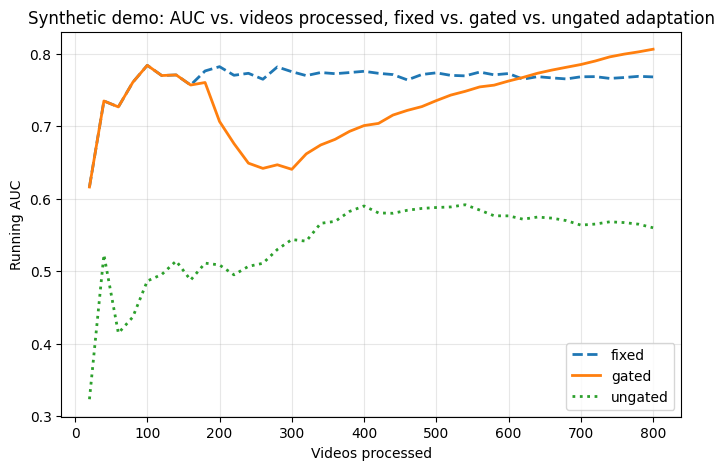

In [ ]:
plt.figure(figsize=(8, 5))
for mode, style in zip(["fixed", "gated", "ungated"], ["--", "-", ":"]):
    xs = [p[0] for p in results[mode]]
    ys = [p[1] for p in results[mode]]
    plt.plot(xs, ys, style, label=mode, linewidth=2)
plt.xlabel("Videos processed")
plt.ylabel("Running AUC")
plt.title("Synthetic demo: AUC vs. videos processed, fixed vs. gated vs. ungated adaptation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
for tau in [0.70, 0.80, 0.90]:
    for alpha in [0.03, 0.08]:
        aucs, n_acc, purity = run_condition("gated", tau_gate=tau, alpha=alpha)
        print(f"tau={tau:.2f}  alpha={alpha:.2f}  accepted={n_acc:4d}  purity={purity:.2f}  final AUC={aucs[-1][1]:.3f}")

tau=0.70  alpha=0.03  accepted= 293  purity=0.82  final AUC=0.789
tau=0.70  alpha=0.08  accepted= 282  purity=0.84  final AUC=0.806
tau=0.80  alpha=0.03  accepted= 225  purity=0.81  final AUC=0.783
tau=0.80  alpha=0.08  accepted= 212  purity=0.84  final AUC=0.806
tau=0.90  alpha=0.03  accepted= 139  purity=0.93  final AUC=0.771
tau=0.90  alpha=0.08  accepted= 130  purity=0.90  final AUC=0.787


In [ ]:
import pandas as pd
import os

DEMO_DIR = "/content/drive/MyDrive/demo_dataset"
meta = pd.read_csv(os.path.join(DEMO_DIR, "videos.csv"))

print(meta["label"].value_counts())
print(meta["source_model"].value_counts())

def resolve_path(row):
    subfolder = "real" if row["label"] == "real" else "fake"
    return os.path.join(DEMO_DIR, subfolder, row["original_filename"])

meta["path"] = meta.apply(resolve_path, axis=1)
missing = meta[~meta["path"].apply(os.path.exists)]
print(f"{len(missing)} listed files not found on disk")
if len(missing):
    print(missing[["original_filename", "path"]].head())

label
fake    27
real     9
Name: count, dtype: int64
source_model
VEO3               13
Sora                5
MSR-VTT             5
MSVD                4
Gen2                3
Text2Video-Zero     1
HotShot             1
LaVie-base          1
VideoCrafter2       1
ModelScope          1
MoonValley          1
Name: count, dtype: int64
36 listed files not found on disk
  original_filename                                               path
0   hotshot_469.mp4  /content/drive/MyDrive/demo_dataset/fake/hotsh...
1       1002478.mp4  /content/drive/MyDrive/demo_dataset/fake/10024...
2      gen2_136.mp4  /content/drive/MyDrive/demo_dataset/fake/gen2_...
3       3002842.mp4  /content/drive/MyDrive/demo_dataset/fake/30028...
4       2000805.mp4  /content/drive/MyDrive/demo_dataset/fake/20008...


In [ ]:
holdout_gen = "VEO3"
in_dist = meta[(meta["source_model"] != holdout_gen)]
held_out = meta[meta["source_model"] == holdout_gen]

real_calib_paths = in_dist[in_dist["label"] == "real"]["path"].tolist()
stream_df = pd.concat([in_dist[in_dist["label"] == "fake"], held_out]).sample(frac=1, random_state=0)
stream_paths = stream_df["path"].tolist()
stream_labels = (stream_df["label"] == "fake").astype(int).tolist()
is_holdout = (stream_df["source_model"] == holdout_gen).tolist()  # keep this to split scores by group later

In [ ]:
import os

actual_fake_files = os.listdir(os.path.join(DEMO_DIR, "fake"))
actual_real_files = os.listdir(os.path.join(DEMO_DIR, "real"))
print(f"actual files in fake/: {len(actual_fake_files)}")
print(f"actual files in real/: {len(actual_real_files)}")
print(actual_fake_files[:10])

expected_fake = meta[meta["label"] == "fake"]["original_filename"].tolist()
print("\nexpected (from csv):", expected_fake[:10])

# case-insensitive / whitespace-insensitive comparison, in case that's the mismatch
actual_lower = {f.strip().lower() for f in actual_fake_files}
missing_even_case_insensitive = [f for f in expected_fake if f.strip().lower() not in actual_lower]
print(f"\nstill missing even case-insensitive: {len(missing_even_case_insensitive)} / {len(expected_fake)}")

actual files in fake/: 9
actual files in real/: 2
['.DS_Store', 'ModelScope', 'VEO3', 'MoonValley', 'Sora', 'Gen2', 'Text2Video-Zero', 'HotShot', 'VideoCrafter2']

expected (from csv): ['hotshot_469.mp4', '1002478.mp4', 'gen2_136.mp4', '3002842.mp4', '2000805.mp4', '4001831.mp4', 'gen2_666.mp4', '96ecfef5-2f15-5dd3-86b0-f63c12eb2290.mp4', '2ad36656-31e4-5940-802a-ae0c57eb9d15.mp4', 'c14ae23b-d3de-581d-bc88-9e3c4930fee0.mp4']

still missing even case-insensitive: 27 / 27


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# check real/ the same way before assuming its structure
print(os.listdir(os.path.join(DEMO_DIR, "real")))

['MSVD', 'MSR-VTT']


In [ ]:
def resolve_path(row):
    subfolder = "real" if row["label"] == "real" else "fake"
    return os.path.join(DEMO_DIR, subfolder, row["source_model"], row["original_filename"])

meta["path"] = meta.apply(resolve_path, axis=1)
missing = meta[~meta["path"].apply(os.path.exists)]
print(f"{len(missing)} listed files not found on disk")
if len(missing):
    print(missing[["source_model", "original_filename", "path"]].head())

36 listed files not found on disk
      source_model original_filename  \
0          HotShot   hotshot_469.mp4   
1  Text2Video-Zero       1002478.mp4   
2             Gen2      gen2_136.mp4   
3       ModelScope       3002842.mp4   
4    VideoCrafter2       2000805.mp4   

                                                path  
0  /content/drive/MyDrive/demo_dataset/fake/HotSh...  
1  /content/drive/MyDrive/demo_dataset/fake/Text2...  
2  /content/drive/MyDrive/demo_dataset/fake/Gen2/...  
3  /content/drive/MyDrive/demo_dataset/fake/Model...  
4  /content/drive/MyDrive/demo_dataset/fake/Video...  


In [ ]:
from sklearn.decomposition import PCA

def fit_pca(embeddings_flat, n_components=16):
    pca = PCA(n_components=n_components, random_state=0)
    pca.fit(embeddings_flat)
    return pca

def apply_pca(embeddings, pca):
    return pca.transform(embeddings)

In [ ]:
import torch
import timm
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
encoder_model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0).to(device).eval()
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def encode_frame(frame_bgr):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    tensor = preprocess(rgb).unsqueeze(0).to(device)
    return encoder_model(tensor).squeeze(0).cpu().numpy()

print(f"Encoder ready on {device}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Encoder ready on cpu


In [ ]:
def extract_frames(video_path, target_fps=8, max_seconds=2):
    cap = cv2.VideoCapture(video_path)
    src_fps = cap.get(cv2.CAP_PROP_FPS) or target_fps
    ratio = max(src_fps / target_fps, 1.0)
    max_frames = int(target_fps * max_seconds)
    frames, j = [], 0
    while True:
        pos = round(ratio * j)
        cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
        ret, frame = cap.read()
        if not ret or len(frames) >= max_frames:
            break
        frames.append(frame)
        j += 1
    cap.release()
    return frames

def embed_video(video_path):
    frames = extract_frames(video_path)
    if len(frames) < 2:
        return None
    return np.stack([encode_frame(f) for f in frames])

In [ ]:
def build_embeddings(paths):
    all_spatial, all_temporal = [], []
    for p in paths:
        emb = embed_video(p)
        if emb is None:
            continue
        all_spatial.append(emb)
        deltas = np.diff(emb, axis=0)
        deltas = deltas / (np.linalg.norm(deltas, axis=1, keepdims=True) + 1e-8)
        all_temporal.append(deltas)
    return all_spatial, all_temporal

In [ ]:
holdout_gen = "VEO3"
in_dist = meta[meta["source_model"] != holdout_gen]
held_out = meta[meta["source_model"] == holdout_gen]

real_calib_paths = in_dist[in_dist["label"] == "real"]["path"].tolist()
stream_df = pd.concat([in_dist[in_dist["label"] == "fake"], held_out]).sample(frac=1, random_state=0)
stream_paths = stream_df["path"].tolist()
stream_labels = (stream_df["label"] == "fake").astype(int).tolist()

# sanity check before proceeding -- if this isn't 0, stop and fix before continuing
print(sum(not os.path.exists(p) for p in real_calib_paths + stream_paths), "paths still missing")

0 paths still missing


In [ ]:
calib_spatial_videos, calib_temporal_videos = build_embeddings(real_calib_paths)
calib_spatial_flat = np.concatenate(calib_spatial_videos, axis=0)
calib_temporal_flat = np.concatenate(calib_temporal_videos, axis=0)

print(calib_spatial_flat.shape)

(144, 768)


In [ ]:
print(calib_temporal_flat.shape)  # sanity check before PCA

pca_spatial = fit_pca(calib_spatial_flat, n_components=16)
pca_temporal = fit_pca(calib_temporal_flat, n_components=16)

calib_spatial_reduced = apply_pca(calib_spatial_flat, pca_spatial)
calib_temporal_reduced = apply_pca(calib_temporal_flat, pca_temporal)

(135, 768)


In [ ]:
detector = OnlineVideoDetector(
    spatial_init=calib_spatial_reduced,
    temporal_init=calib_temporal_reduced,
    alpha=0.08, gate_window=200, tau_gate=0.80,
)

In [ ]:
fake_scores, source_models, aligned_stream_labels = [], [], []
for i, p in enumerate(stream_paths):
    emb = embed_video(p)
    if emb is None:
        continue
    emb_reduced = apply_pca(emb, pca_spatial)
    combined_perc, fake_score, _, _ = detector.score_video(emb_reduced)
    fake_scores.append(fake_score)
    source_models.append(stream_df.iloc[i]["source_model"])
    aligned_stream_labels.append(stream_labels[i])

results_df = pd.DataFrame({"source_model": source_models, "fake_score": fake_scores})
print(results_df.groupby("source_model")["fake_score"].agg(["mean", "count"]).sort_values("mean"))

KeyboardInterrupt: 

In [ ]:
real_rows = meta[meta["label"] == "real"].sample(frac=1, random_state=0)
n_calib_real = 5  # keep a handful for calibration, hold out the rest
calib_real_rows = real_rows.iloc[:n_calib_real]
stream_real_rows = real_rows.iloc[n_calib_real:]

real_calib_paths = calib_real_rows["path"].tolist()

stream_df = pd.concat([
    in_dist[in_dist["label"] == "fake"],
    held_out,
    stream_real_rows,
]).sample(frac=1, random_state=0)
stream_paths = stream_df["path"].tolist()
stream_labels = (stream_df["label"] == "fake").astype(int).tolist()

print(stream_df["label"].value_counts())  # confirm both classes are actually present now

label
fake    26
real     4
Name: count, dtype: int64


In [ ]:
fake_scores, kept_labels, source_models = [], [], []
n_skipped = 0
for i, p in enumerate(stream_paths):
    emb = embed_video(p)
    if emb is None:
        n_skipped += 1
        continue
    emb_reduced = apply_pca(emb, pca_spatial)
    combined_perc, fake_score, _, _ = detector.score_video(emb_reduced)
    fake_scores.append(fake_score)
    kept_labels.append(stream_labels[i])
    source_models.append(stream_df.iloc[i]["source_model"])

print(f"skipped {n_skipped} videos (embed_video returned None)")
print("AUC:", roc_auc_score(kept_labels, fake_scores))

skipped 0 videos (embed_video returned None)
AUC: 0.038461538461538464


In [ ]:
def raw_fake_score(detector, frame_embeddings):
    y_spat = detector.spatial._whiten(frame_embeddings, detector.spatial.mu)
    spat_min = detector.spatial._loglik(y_spat).min()  # least-typical frame

    deltas = np.diff(frame_embeddings, axis=0)
    deltas = deltas / (np.linalg.norm(deltas, axis=1, keepdims=True) + 1e-8)
    if len(deltas) > 0:
        y_temp = detector.temporal._whiten(deltas, detector.temporal.mu)
        temp_min = detector.temporal._loglik(y_temp).min()
    else:
        temp_min = 0.0

    return -(spat_min + temp_min)  # higher = less likely under the real-video model = more fake-like

fake_scores, kept_labels, source_models = [], [], []
for i, p in enumerate(stream_paths):
    emb = embed_video(p)
    if emb is None:
        continue
    emb_reduced = apply_pca(emb, pca_spatial)
    fake_scores.append(raw_fake_score(detector, emb_reduced))
    kept_labels.append(stream_labels[i])
    source_models.append(stream_df.iloc[i]["source_model"])

print("AUC:", roc_auc_score(kept_labels, fake_scores))

AUC: 0.009615384615384616


In [ ]:
def raw_fake_score(detector, emb_raw, pca_spatial, pca_temporal):
    # spatial: reduce raw frame embeddings, score against spatial branch
    emb_spatial_reduced = apply_pca(emb_raw, pca_spatial)
    y_spat = detector.spatial._whiten(emb_spatial_reduced, detector.spatial.mu)
    spat_min = detector.spatial._loglik(y_spat).min()

    # temporal: diffs computed on RAW embeddings FIRST, normalized, THEN reduced --
    # this must mirror build_embeddings exactly, or it's scoring against the wrong space
    deltas_raw = np.diff(emb_raw, axis=0)
    deltas_raw = deltas_raw / (np.linalg.norm(deltas_raw, axis=1, keepdims=True) + 1e-8)
    if len(deltas_raw) > 0:
        deltas_reduced = apply_pca(deltas_raw, pca_temporal)
        y_temp = detector.temporal._whiten(deltas_reduced, detector.temporal.mu)
        temp_min = detector.temporal._loglik(y_temp).min()
    else:
        temp_min = 0.0

    return -(spat_min + temp_min)

fake_scores, kept_labels, source_models = [], [], []
for i, p in enumerate(stream_paths):
    emb = embed_video(p)  # RAW 768-dim, not yet reduced
    if emb is None:
        continue
    fake_scores.append(raw_fake_score(detector, emb, pca_spatial, pca_temporal))
    kept_labels.append(stream_labels[i])
    source_models.append(stream_df.iloc[i]["source_model"])

print("AUC:", roc_auc_score(kept_labels, fake_scores))

AUC: 0.0


In [ ]:
import pandas as pd
check_df = pd.DataFrame({"label": kept_labels, "fake_score": fake_scores})
print(check_df.groupby("label")["fake_score"].describe())

       count       mean        std        min        25%        50%  \
label                                                                 
0        4.0  58.600824  15.122037  47.399659  49.236230  53.245552   
1       26.0  35.002755   1.758473  32.939754  33.618693  34.412068   

             75%        max  
label                        
0      62.610147  80.512534  
1      35.791958  39.207643  


In [ ]:
print(calib_real_rows[["source_model", "id"]])
print(stream_real_rows[["source_model", "id"]])

   source_model     id
33         MSVD  10282
28      MSR-VTT   8807
27      MSR-VTT   6770
30      MSR-VTT   6501
34         MSVD   9930
   source_model     id
32         MSVD   9671
29         MSVD  10732
26      MSR-VTT   6673
31      MSR-VTT   6282


In [ ]:
print("flipped AUC:", roc_auc_score([1 - l for l in kept_labels], fake_scores))

flipped AUC: 1.0
